In [4]:
# notebooks/technical_analysis_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ EDA Environment Ready!")

# Load processed data
def load_processed_data():
    """Load all processed stock data"""
    processed_dir = "../data/processed"
    files = {
        'AAPL': 'AAPL_1mo_1d_processed.csv',
        'MSFT': 'MSFT_6mo_1d_processed.csv', 
        'GOOGL': 'GOOGL_1y_1wk_processed.csv'
    }
    
    data = {}
    for ticker, filename in files.items():
        filepath = os.path.join(processed_dir, filename)
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, index_col=0, parse_dates=True)
            data[ticker] = df
            print(f"✅ Loaded {ticker}: {df.shape} | {df.index.min()} to {df.index.max()}")
        else:
            print(f"❌ File not found: {filepath}")
    
    return data

# Load the data
stock_data = load_processed_data()

✅ EDA Environment Ready!
✅ Loaded AAPL: (23, 16) | 2025-09-22 00:00:00 to 2025-10-22 00:00:00
✅ Loaded MSFT: (128, 16) | 2025-04-22 00:00:00 to 2025-10-22 00:00:00
✅ Loaded GOOGL: (53, 16) | 2024-10-21 00:00:00 to 2025-10-20 00:00:00


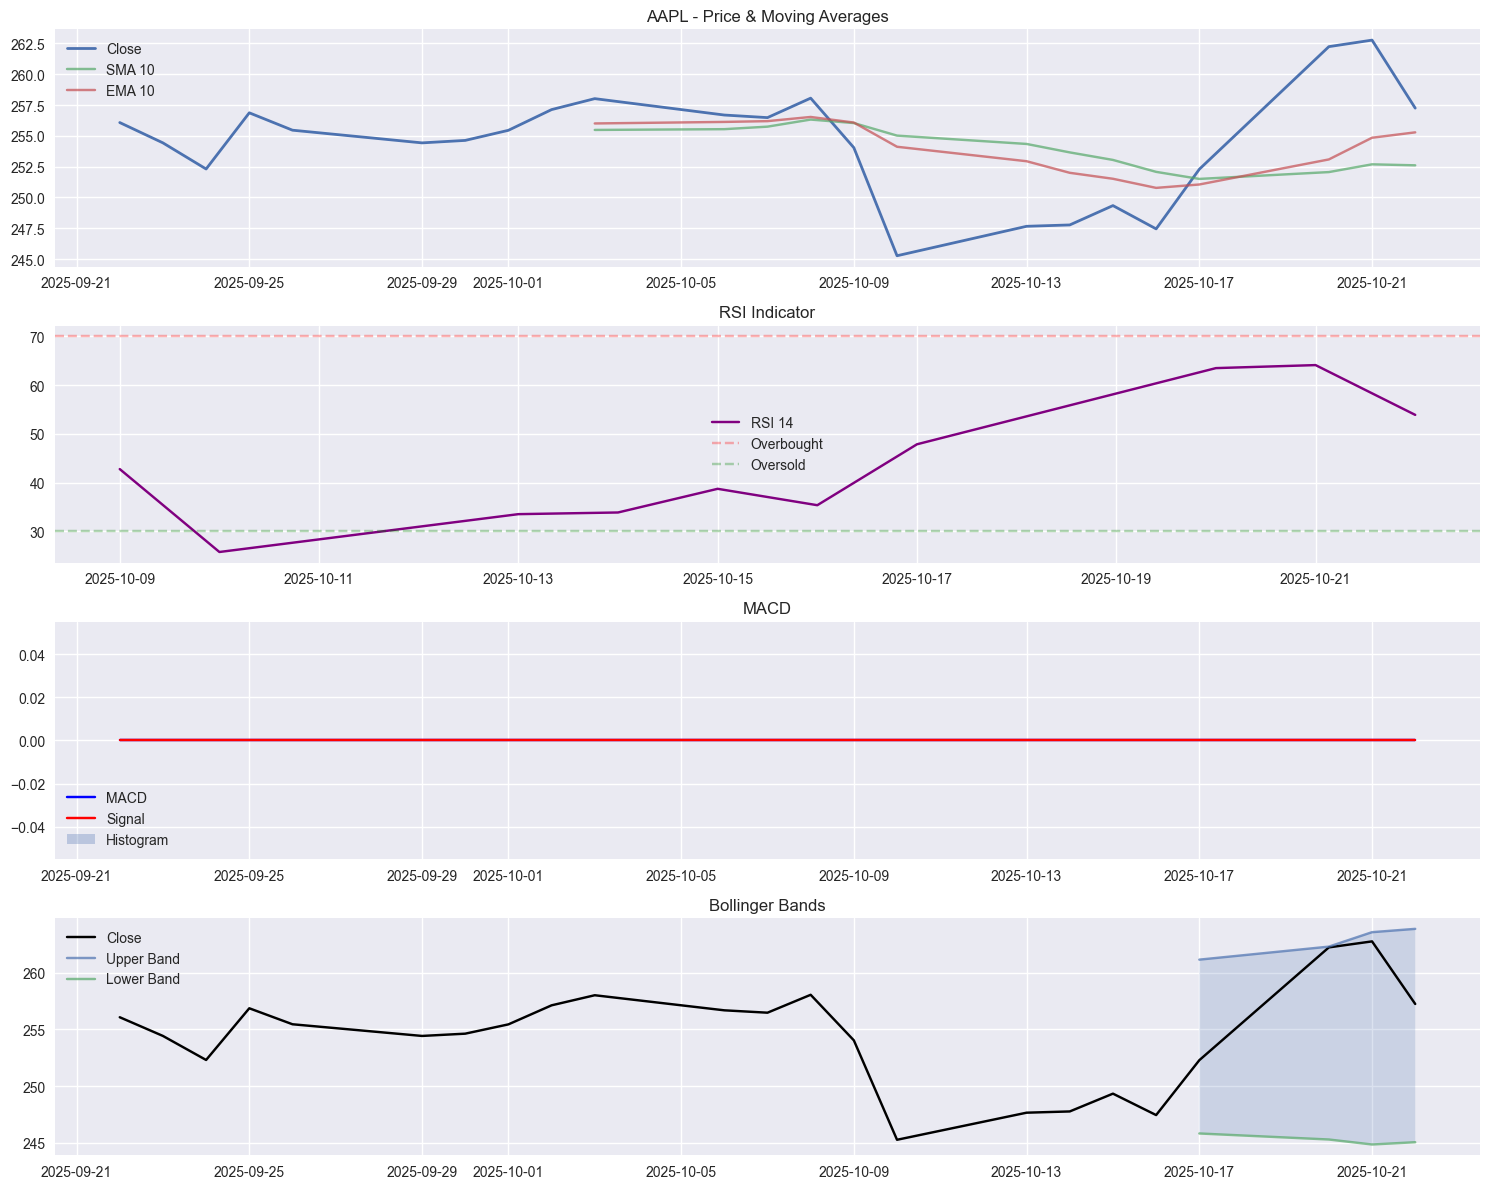

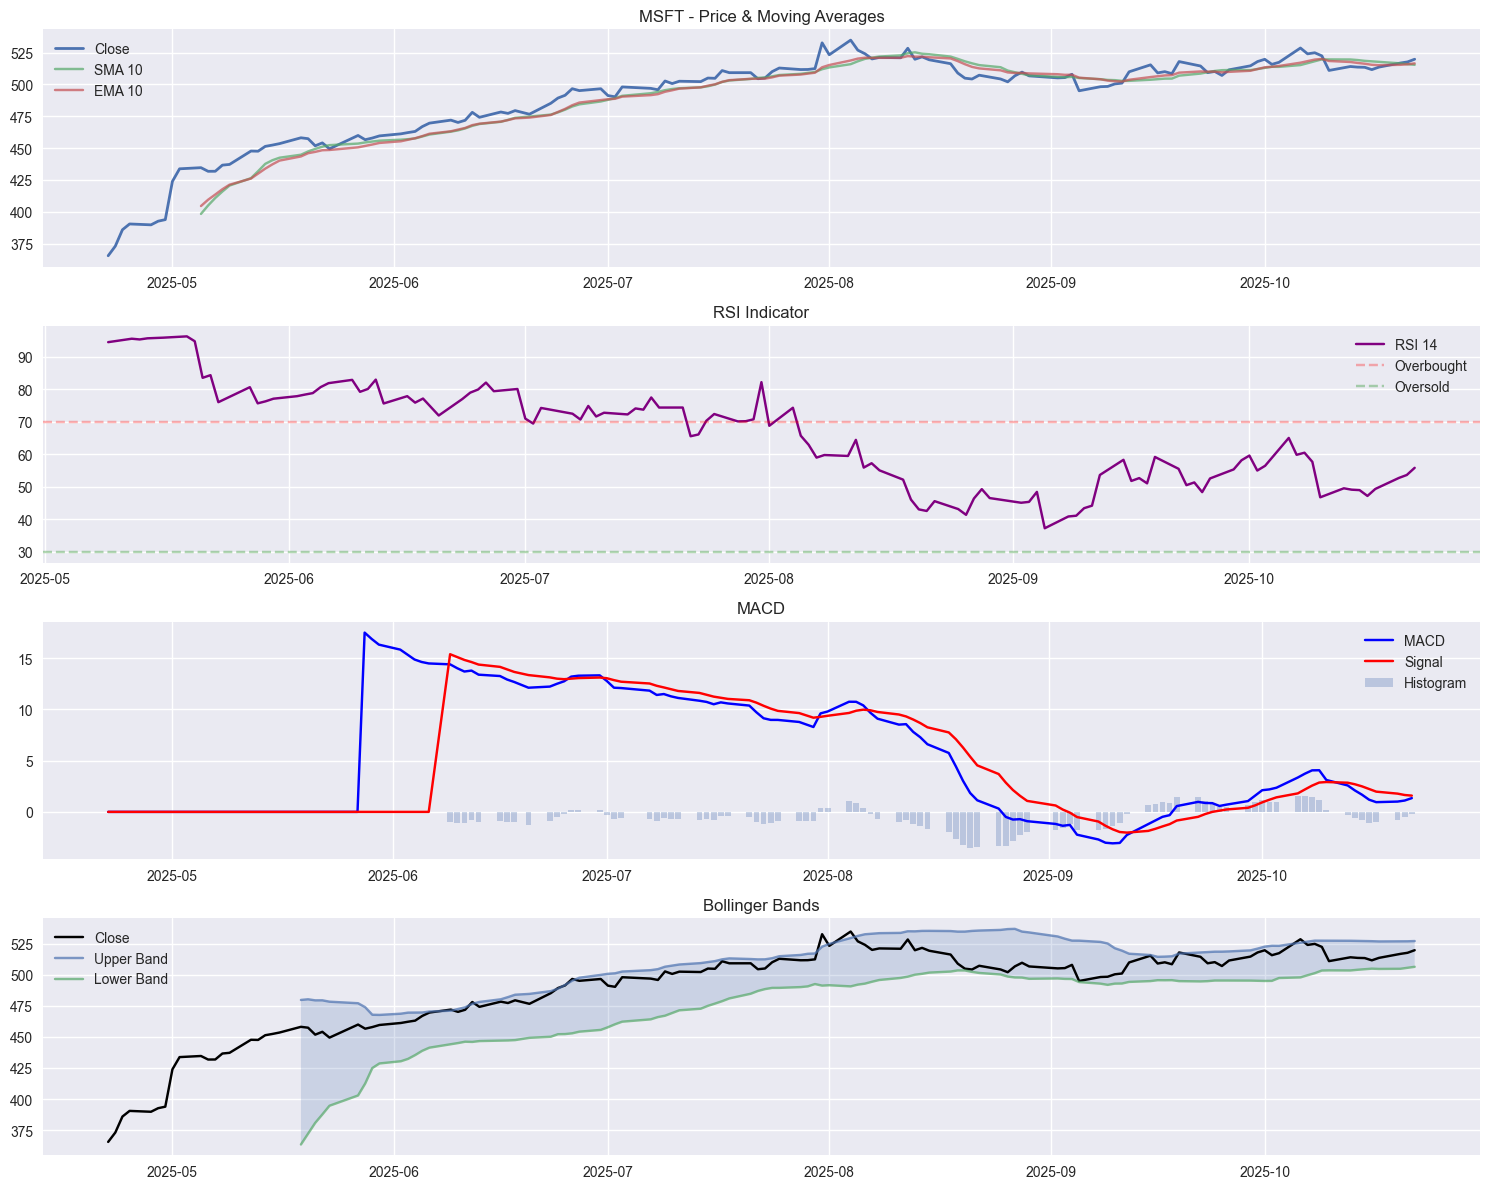

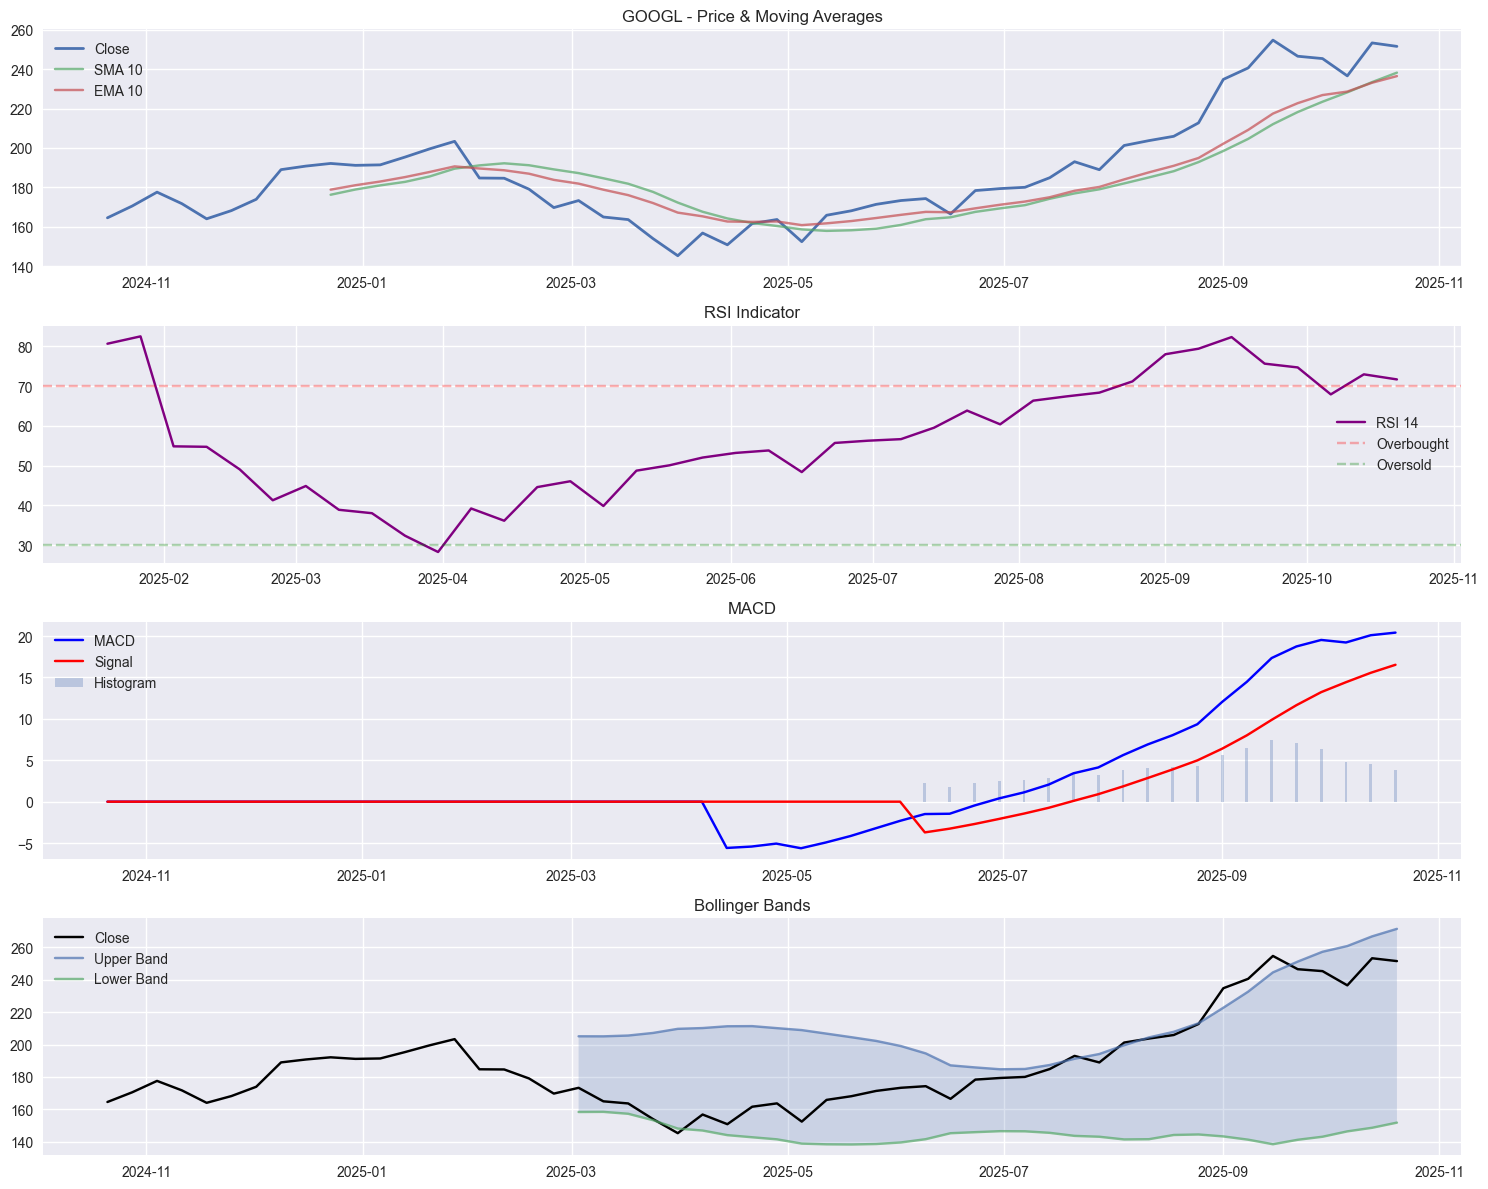

In [8]:
def plot_technical_indicators(ticker, df):
    """Plot price with technical indicators"""
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    
    # Price with SMA/EMA
    axes[0].plot(df.index, df['Close'], label='Close', linewidth=2)
    axes[0].plot(df.index, df['SMA_10'], label='SMA 10', alpha=0.7)
    axes[0].plot(df.index, df['EMA_10'], label='EMA 10', alpha=0.7)
    axes[0].set_title(f'{ticker} - Price & Moving Averages')
    axes[0].legend()
    axes[0].grid(True)
    
    # RSI
    axes[1].plot(df.index, df['RSI_14'], label='RSI 14', color='purple')
    axes[1].axhline(70, linestyle='--', alpha=0.3, color='red', label='Overbought')
    axes[1].axhline(30, linestyle='--', alpha=0.3, color='green', label='Oversold')
    axes[1].set_title('RSI Indicator')
    axes[1].legend()
    axes[1].grid(True)

    # Clean MACD data for plotting
    df = df.copy()
    df['MACD'] = df['MACD'].replace([np.inf, -np.inf], np.nan).fillna(0)
    df['MACD_Signal'] = df['MACD_Signal'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # MACD
    axes[2].plot(df.index, df['MACD'], label='MACD', color='blue')
    axes[2].plot(df.index, df['MACD_Signal'], label='Signal', color='red')
    axes[2].bar(df.index, df['MACD_Histogram'], label='Histogram', alpha=0.3)
    axes[2].set_title('MACD')
    axes[2].legend()
    axes[2].grid(True)
    
    # Bollinger Bands
    axes[3].plot(df.index, df['Close'], label='Close', color='black')
    axes[3].plot(df.index, df['Bollinger_High'], label='Upper Band', alpha=0.7)
    axes[3].plot(df.index, df['Bollinger_Low'], label='Lower Band', alpha=0.7)
    axes[3].fill_between(df.index, df['Bollinger_High'], df['Bollinger_Low'], alpha=0.2)
    axes[3].set_title('Bollinger Bands')
    axes[3].legend()
    axes[3].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot for each stock
for ticker, df in stock_data.items():
    plot_technical_indicators(ticker, df)

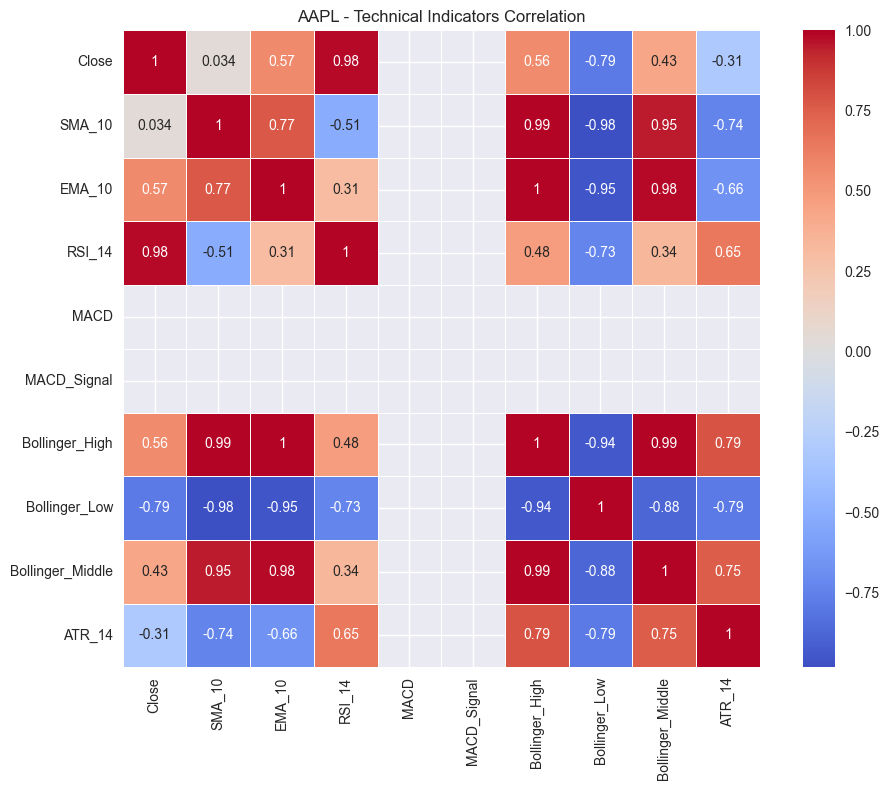

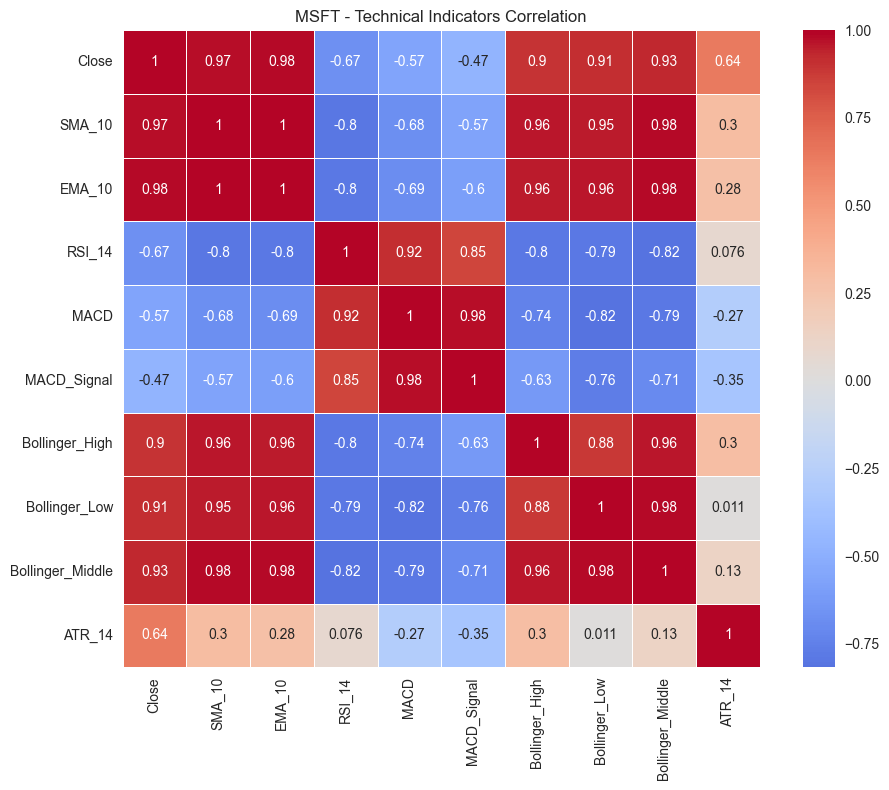

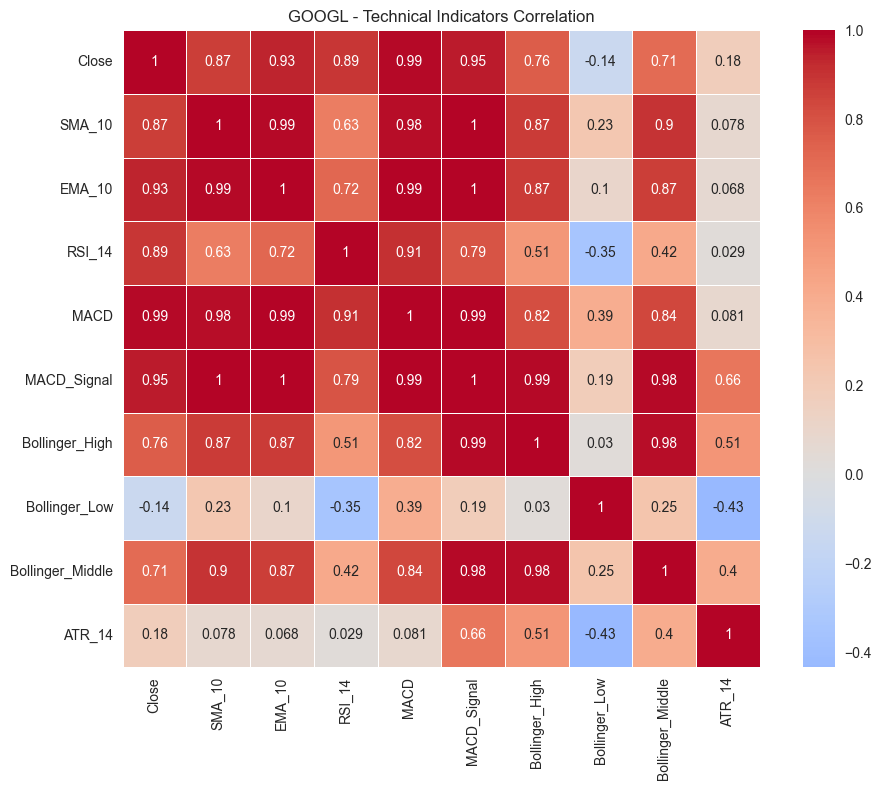

In [6]:
# Correlation heatmap for technical indicators
def plot_correlation_heatmap(ticker, df):
    """Plot correlation between indicators and price movements"""
    # Calculate price changes
    price_cols = ['Close', 'SMA_10', 'EMA_10', 'RSI_14', 'MACD', 'MACD_Signal', 
                  'Bollinger_High', 'Bollinger_Low', 'Bollinger_Middle', 'ATR_14']
    
    available_cols = [col for col in price_cols if col in df.columns]
    corr_matrix = df[available_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title(f'{ticker} - Technical Indicators Correlation')
    plt.tight_layout()
    plt.show()

for ticker, df in stock_data.items():
    plot_correlation_heatmap(ticker, df)

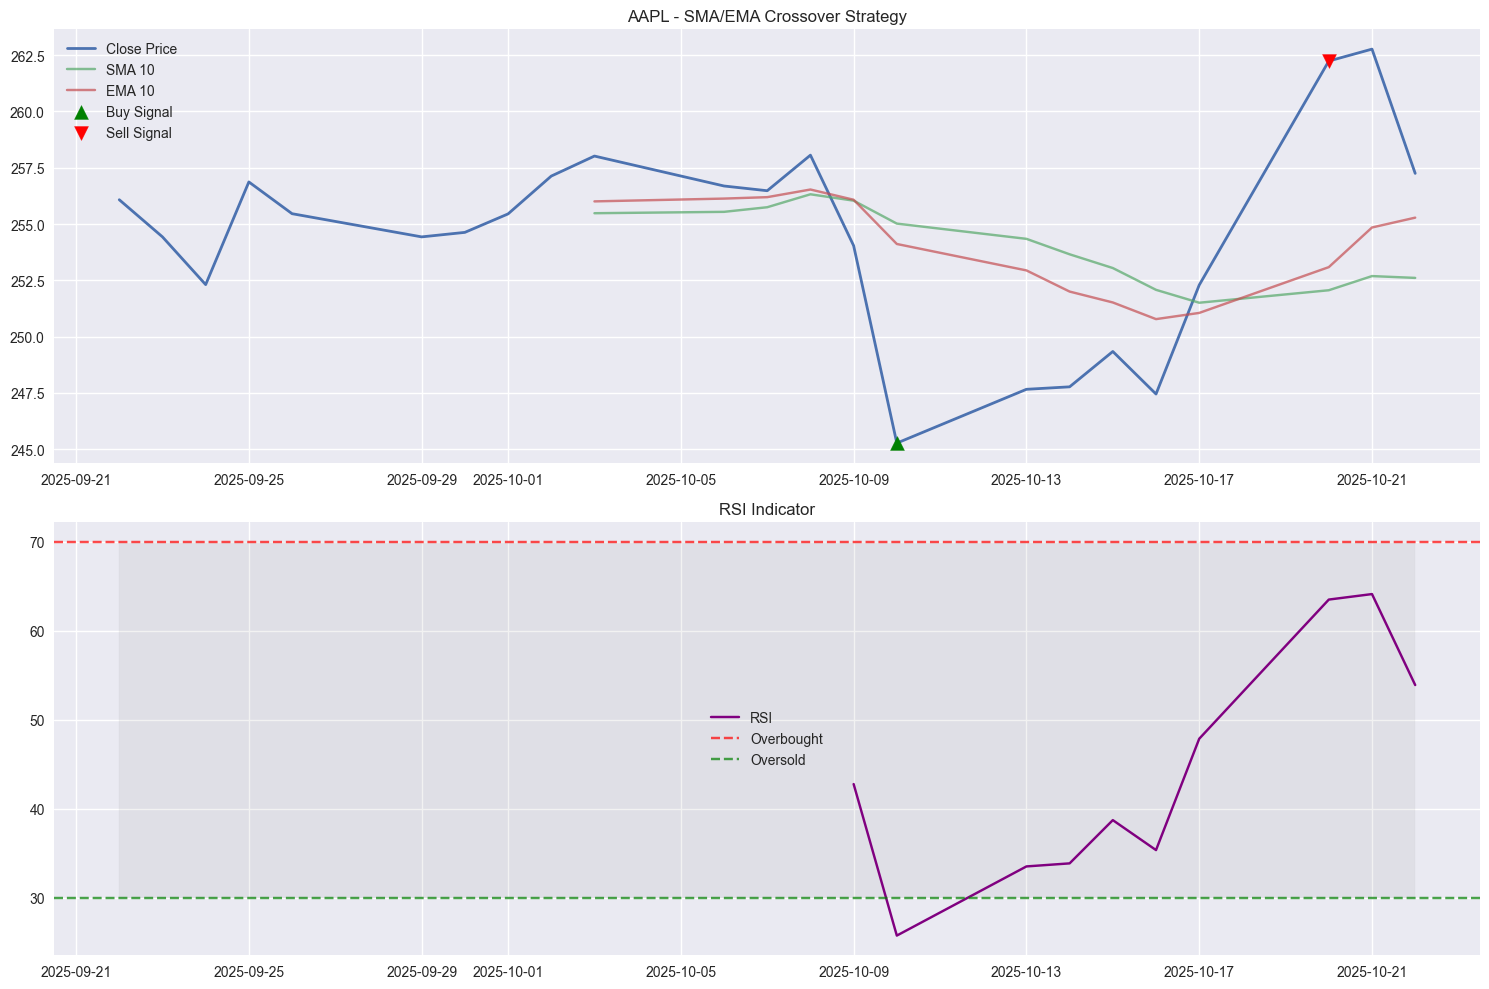

📈 AAPL Strategy Signals:
   Buy opportunities: 1
   Sell opportunities: 1


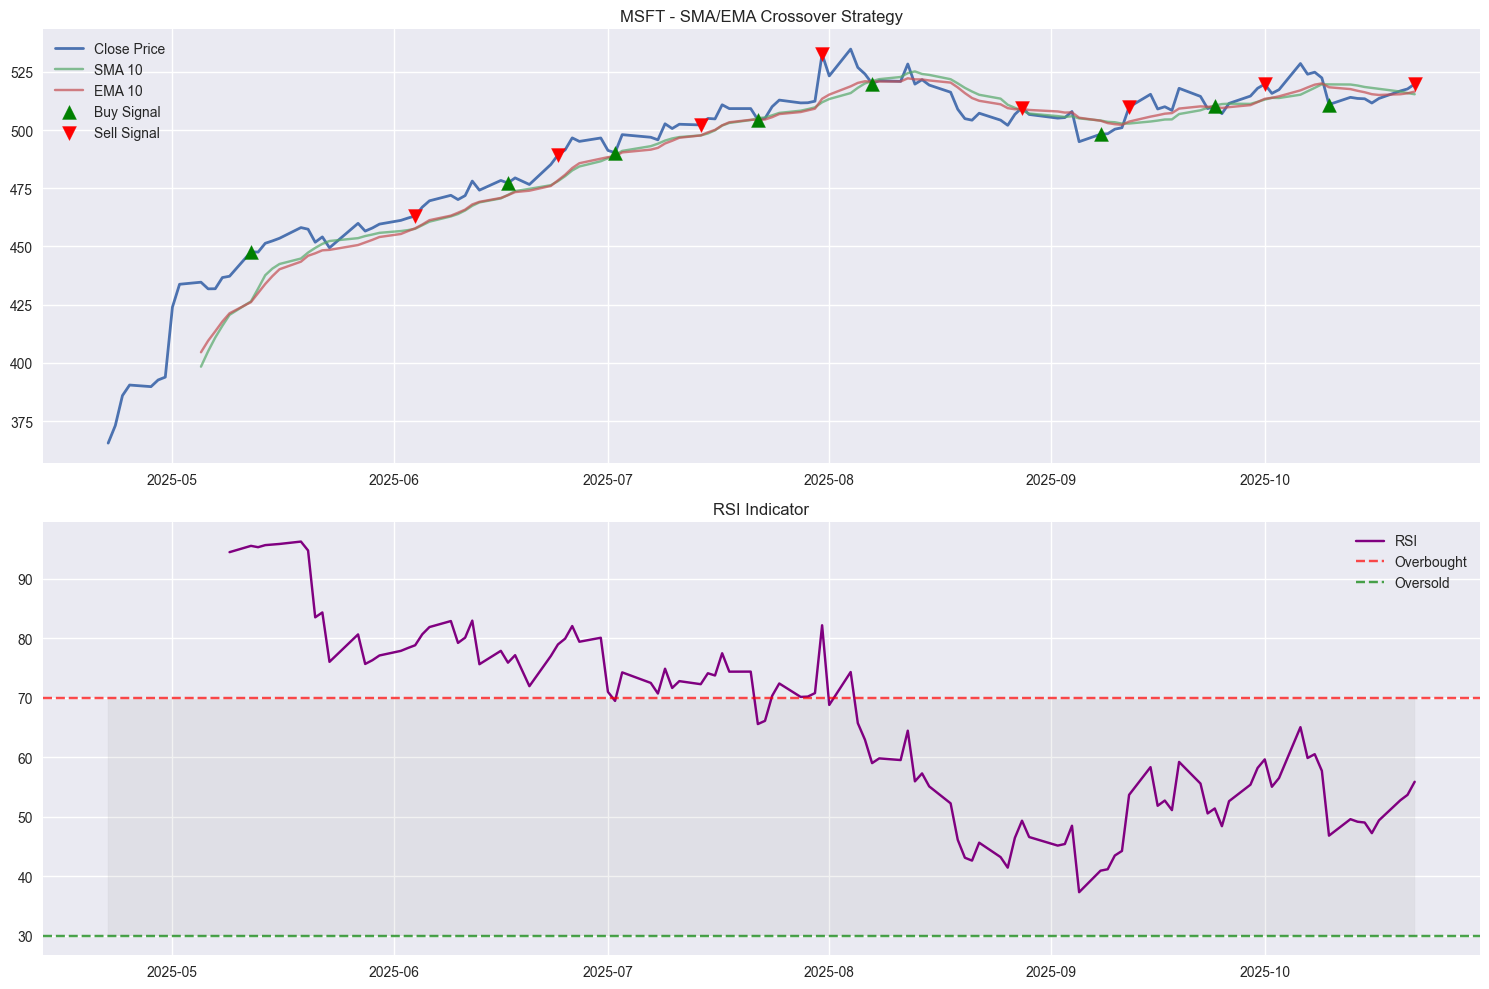

📈 MSFT Strategy Signals:
   Buy opportunities: 8
   Sell opportunities: 8


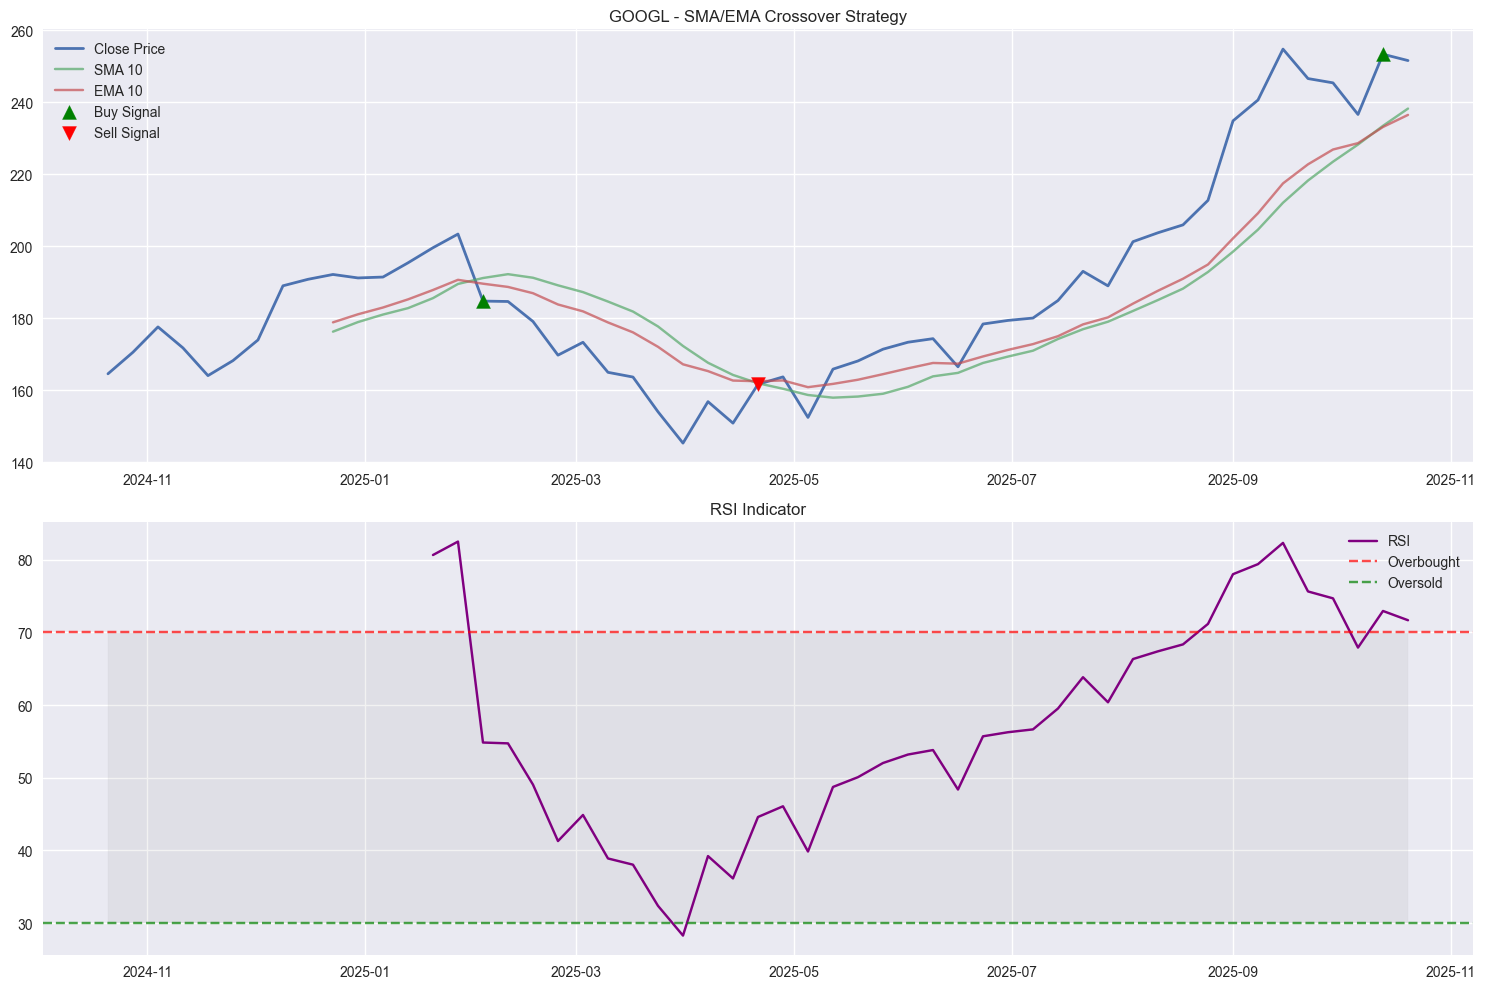

📈 GOOGL Strategy Signals:
   Buy opportunities: 2
   Sell opportunities: 1


In [7]:
def visualize_simple_strategy(ticker, df):
    """Visualize a simple SMA crossover strategy"""
    # Create signals
    df['SMA_Signal'] = np.where(df['SMA_10'] > df['EMA_10'], 1, -1)
    df['Position'] = df['SMA_Signal'].diff()
    
    # Plot
    plt.figure(figsize=(15, 10))
    
    # Price and MAs
    plt.subplot(2, 1, 1)
    plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
    plt.plot(df.index, df['SMA_10'], label='SMA 10', alpha=0.7)
    plt.plot(df.index, df['EMA_10'], label='EMA 10', alpha=0.7)
    
    # Buy signals (SMA crosses above EMA)
    buy_signals = df[df['Position'] == 2]
    plt.scatter(buy_signals.index, buy_signals['Close'], 
                color='green', marker='^', s=100, label='Buy Signal', zorder=5)
    
    # Sell signals (SMA crosses below EMA)  
    sell_signals = df[df['Position'] == -2]
    plt.scatter(sell_signals.index, sell_signals['Close'],
                color='red', marker='v', s=100, label='Sell Signal', zorder=5)
    
    plt.title(f'{ticker} - SMA/EMA Crossover Strategy')
    plt.legend()
    plt.grid(True)
    
    # RSI with overbought/oversold
    plt.subplot(2, 1, 2)
    plt.plot(df.index, df['RSI_14'], label='RSI', color='purple')
    plt.axhline(70, linestyle='--', alpha=0.7, color='red', label='Overbought')
    plt.axhline(30, linestyle='--', alpha=0.7, color='green', label='Oversold')
    plt.fill_between(df.index, 70, 30, alpha=0.1, color='gray')
    plt.title('RSI Indicator')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print strategy stats
    if len(buy_signals) > 0:
        print(f"📈 {ticker} Strategy Signals:")
        print(f"   Buy opportunities: {len(buy_signals)}")
        print(f"   Sell opportunities: {len(sell_signals)}")

for ticker, df in stock_data.items():
    visualize_simple_strategy(ticker, df)